In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [401]:
path_to_csv = "datasetz.csv"
data = pd.read_csv(path_to_csv,encoding="ISO-8859–1",index_col=False)
data.shape

(6769, 16)

In [402]:
data.dtypes # Checking the datatypes

FIRST_NAME           object
LAST_NAME            object
DEPARTMENT           object
JOB_TITLE            object
ELECTED_OFFICIAL      int64
DATE_STARTED         object
SEX                  object
ETHNICITY            object
ORIG_START           object
DATE_TERM            object
PAY_STATUS           object
ANNUAL_SALARY       float64
REGULAR_PAY         float64
OVERTIME_PAY        float64
INCENTIVE_PAY       float64
GROSS_PAY           float64
dtype: object

In [403]:
data.isnull()

,FIRST_NAME,LAST_NAME,DEPARTMENT,JOB_TITLE,ELECTED_OFFICIAL,DATE_STARTED,SEX,ETHNICITY,ORIG_START,DATE_TERM,PAY_STATUS,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6764,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6765,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
6766,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
6767,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [404]:
data=data.replace(to_replace = '',value= np.nan)

In [405]:
data['DATE_STARTED'] =  pd.to_datetime(data['DATE_STARTED'], format='%m/%d/%Y')
data['ORIG_START'] =  pd.to_datetime(data['ORIG_START'], format='%m/%d/%Y')
data['DATE_TERM'] =  pd.to_datetime(data['DATE_TERM'], format='%m/%d/%Y')
data.dtypes

FIRST_NAME                  object
LAST_NAME                   object
DEPARTMENT                  object
JOB_TITLE                   object
ELECTED_OFFICIAL             int64
DATE_STARTED        datetime64[ns]
SEX                         object
ETHNICITY                   object
ORIG_START          datetime64[ns]
DATE_TERM           datetime64[ns]
PAY_STATUS                  object
ANNUAL_SALARY              float64
REGULAR_PAY                float64
OVERTIME_PAY               float64
INCENTIVE_PAY              float64
GROSS_PAY                  float64
dtype: object

In [406]:
u = data.select_dtypes(include=['datetime'])
datex=pd.to_datetime('today').strftime("%m/%d/%Y")
data[u.columns] = u.fillna(datex)
data

,FIRST_NAME,LAST_NAME,DEPARTMENT,JOB_TITLE,ELECTED_OFFICIAL,DATE_STARTED,SEX,ETHNICITY,ORIG_START,DATE_TERM,PAY_STATUS,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY
0,DOMINIKA L,AARON,Human Services,CASEWORKER - CYF,0,2019-05-13,F,Black,2019-05-13,2019-05-31,Terminated,35821.34,1239.93,0.00,0.00,1239.93
1,CATHERINE,ABALO,Kane Regional Centers,NURSING ASSISTANT,0,2010-04-08,F,Black,2009-07-06,2022-07-10,Active,39771.47,43451.14,21377.48,0.00,64828.62
2,JOY M,ABBOTT,Kane Regional Centers,COOK,0,1999-02-14,F,White (Not of Hispanic Origin),1998-02-02,2022-07-10,Active,38987.73,39557.80,7826.11,125.00,47508.91
3,KEVIN J,ABBOTT,Emergency Management,FIRE INSTRUCTOR - PART TIME,0,2018-06-11,M,White (Not of Hispanic Origin),2018-06-11,2022-07-10,Active,30576.00,336.00,0.00,0.00,336.00
4,JEROME J,ABMAYR,Facilities Management,FOREMAN BUILDING MAINTENANCE,0,2010-05-10,M,White (Not of Hispanic Origin),2010-05-10,2019-03-29,Terminated,42975.30,18365.26,108.47,0.00,18473.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6764,ALBERT,ZUPANCIC,Public Works Operating,REGIONAL MAINTENANCE SPRV,0,2017-08-21,M,White (Not of Hispanic Origin),2017-08-21,2019-04-11,Terminated,56671.47,15257.72,0.00,0.00,15257.72
6765,ILAN,ZUR,District Attorney,DEPUTY DISTRICT ATTORNEY,0,1998-10-05,M,White (Not of Hispanic Origin),1998-10-05,2022-07-10,Active,102051.66,102052.46,0.00,0.00,102052.46
6766,JEFFREY M.,ZURISKO,District Attorney,ATTORNEY 3,0,2006-11-20,M,White (Not of Hispanic Origin),2006-11-20,2022-07-10,Active,51423.42,53260.30,3467.81,1028.47,57756.58
6767,MARY E,ZUSINAS,Public Works Operating,ADMINISTRATIVE ASSISTANT,0,2013-05-20,F,White (Not of Hispanic Origin),2013-05-20,2022-07-10,Active,32818.66,32787.21,0.00,0.00,32787.21


In [407]:
from datetime import date
date=date.today().strftime("%m/%d/%Y")
data['DATE_TERM'].fillna(date)
data['YEAR_EXPERIENCE'] = data['DATE_TERM'] - data['ORIG_START'] 
data['YEAR_EXPERIENCE']=data['YEAR_EXPERIENCE'] / np.timedelta64(1, 'Y')
data['YEAR_EXPERIENCE']=data['YEAR_EXPERIENCE'].astype(int)
data

,FIRST_NAME,LAST_NAME,DEPARTMENT,JOB_TITLE,ELECTED_OFFICIAL,DATE_STARTED,SEX,ETHNICITY,ORIG_START,DATE_TERM,PAY_STATUS,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY,YEAR_EXPERIENCE
0,DOMINIKA L,AARON,Human Services,CASEWORKER - CYF,0,2019-05-13,F,Black,2019-05-13,2019-05-31,Terminated,35821.34,1239.93,0.00,0.00,1239.93,0
1,CATHERINE,ABALO,Kane Regional Centers,NURSING ASSISTANT,0,2010-04-08,F,Black,2009-07-06,2022-07-10,Active,39771.47,43451.14,21377.48,0.00,64828.62,13
2,JOY M,ABBOTT,Kane Regional Centers,COOK,0,1999-02-14,F,White (Not of Hispanic Origin),1998-02-02,2022-07-10,Active,38987.73,39557.80,7826.11,125.00,47508.91,24
3,KEVIN J,ABBOTT,Emergency Management,FIRE INSTRUCTOR - PART TIME,0,2018-06-11,M,White (Not of Hispanic Origin),2018-06-11,2022-07-10,Active,30576.00,336.00,0.00,0.00,336.00,4
4,JEROME J,ABMAYR,Facilities Management,FOREMAN BUILDING MAINTENANCE,0,2010-05-10,M,White (Not of Hispanic Origin),2010-05-10,2019-03-29,Terminated,42975.30,18365.26,108.47,0.00,18473.73,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6764,ALBERT,ZUPANCIC,Public Works Operating,REGIONAL MAINTENANCE SPRV,0,2017-08-21,M,White (Not of Hispanic Origin),2017-08-21,2019-04-11,Terminated,56671.47,15257.72,0.00,0.00,15257.72,1
6765,ILAN,ZUR,District Attorney,DEPUTY DISTRICT ATTORNEY,0,1998-10-05,M,White (Not of Hispanic Origin),1998-10-05,2022-07-10,Active,102051.66,102052.46,0.00,0.00,102052.46,23
6766,JEFFREY M.,ZURISKO,District Attorney,ATTORNEY 3,0,2006-11-20,M,White (Not of Hispanic Origin),2006-11-20,2022-07-10,Active,51423.42,53260.30,3467.81,1028.47,57756.58,15
6767,MARY E,ZUSINAS,Public Works Operating,ADMINISTRATIVE ASSISTANT,0,2013-05-20,F,White (Not of Hispanic Origin),2013-05-20,2022-07-10,Active,32818.66,32787.21,0.00,0.00,32787.21,9


In [408]:
data.dtypes

FIRST_NAME                  object
LAST_NAME                   object
DEPARTMENT                  object
JOB_TITLE                   object
ELECTED_OFFICIAL             int64
DATE_STARTED        datetime64[ns]
SEX                         object
ETHNICITY                   object
ORIG_START          datetime64[ns]
DATE_TERM           datetime64[ns]
PAY_STATUS                  object
ANNUAL_SALARY              float64
REGULAR_PAY                float64
OVERTIME_PAY               float64
INCENTIVE_PAY              float64
GROSS_PAY                  float64
YEAR_EXPERIENCE              int32
dtype: object

In [409]:
#Missing Value Ratio
data.isnull().sum()

FIRST_NAME          2
LAST_NAME           0
DEPARTMENT          0
JOB_TITLE           0
ELECTED_OFFICIAL    0
DATE_STARTED        0
SEX                 0
ETHNICITY           0
ORIG_START          0
DATE_TERM           0
PAY_STATUS          0
ANNUAL_SALARY       0
REGULAR_PAY         0
OVERTIME_PAY        0
INCENTIVE_PAY       0
GROSS_PAY           0
YEAR_EXPERIENCE     0
dtype: int64

In [410]:
# percentage of missing values in each variable
data.isnull().sum()/len(data)*100

FIRST_NAME          0.029546
LAST_NAME           0.000000
DEPARTMENT          0.000000
JOB_TITLE           0.000000
ELECTED_OFFICIAL    0.000000
DATE_STARTED        0.000000
SEX                 0.000000
ETHNICITY           0.000000
ORIG_START          0.000000
DATE_TERM           0.000000
PAY_STATUS          0.000000
ANNUAL_SALARY       0.000000
REGULAR_PAY         0.000000
OVERTIME_PAY        0.000000
INCENTIVE_PAY       0.000000
GROSS_PAY           0.000000
YEAR_EXPERIENCE     0.000000
dtype: float64

In [411]:
# saving missing values in a variable
a = data.isnull().sum()/len(data)*100
# saving column names in a variable
variables = data.columns
variable = [ ]
for i in range(0,17):
    if a[i]<=20:   #setting the threshold as 20%
        variable.append(variables[i])

In [412]:
new_data = data[variable]
new_data

,FIRST_NAME,LAST_NAME,DEPARTMENT,JOB_TITLE,ELECTED_OFFICIAL,DATE_STARTED,SEX,ETHNICITY,ORIG_START,DATE_TERM,PAY_STATUS,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY,YEAR_EXPERIENCE
0,DOMINIKA L,AARON,Human Services,CASEWORKER - CYF,0,2019-05-13,F,Black,2019-05-13,2019-05-31,Terminated,35821.34,1239.93,0.00,0.00,1239.93,0
1,CATHERINE,ABALO,Kane Regional Centers,NURSING ASSISTANT,0,2010-04-08,F,Black,2009-07-06,2022-07-10,Active,39771.47,43451.14,21377.48,0.00,64828.62,13
2,JOY M,ABBOTT,Kane Regional Centers,COOK,0,1999-02-14,F,White (Not of Hispanic Origin),1998-02-02,2022-07-10,Active,38987.73,39557.80,7826.11,125.00,47508.91,24
3,KEVIN J,ABBOTT,Emergency Management,FIRE INSTRUCTOR - PART TIME,0,2018-06-11,M,White (Not of Hispanic Origin),2018-06-11,2022-07-10,Active,30576.00,336.00,0.00,0.00,336.00,4
4,JEROME J,ABMAYR,Facilities Management,FOREMAN BUILDING MAINTENANCE,0,2010-05-10,M,White (Not of Hispanic Origin),2010-05-10,2019-03-29,Terminated,42975.30,18365.26,108.47,0.00,18473.73,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6764,ALBERT,ZUPANCIC,Public Works Operating,REGIONAL MAINTENANCE SPRV,0,2017-08-21,M,White (Not of Hispanic Origin),2017-08-21,2019-04-11,Terminated,56671.47,15257.72,0.00,0.00,15257.72,1
6765,ILAN,ZUR,District Attorney,DEPUTY DISTRICT ATTORNEY,0,1998-10-05,M,White (Not of Hispanic Origin),1998-10-05,2022-07-10,Active,102051.66,102052.46,0.00,0.00,102052.46,23
6766,JEFFREY M.,ZURISKO,District Attorney,ATTORNEY 3,0,2006-11-20,M,White (Not of Hispanic Origin),2006-11-20,2022-07-10,Active,51423.42,53260.30,3467.81,1028.47,57756.58,15
6767,MARY E,ZUSINAS,Public Works Operating,ADMINISTRATIVE ASSISTANT,0,2013-05-20,F,White (Not of Hispanic Origin),2013-05-20,2022-07-10,Active,32818.66,32787.21,0.00,0.00,32787.21,9


In [413]:
#Missing Value Ratio
new_data.isnull().sum()

FIRST_NAME          2
LAST_NAME           0
DEPARTMENT          0
JOB_TITLE           0
ELECTED_OFFICIAL    0
DATE_STARTED        0
SEX                 0
ETHNICITY           0
ORIG_START          0
DATE_TERM           0
PAY_STATUS          0
ANNUAL_SALARY       0
REGULAR_PAY         0
OVERTIME_PAY        0
INCENTIVE_PAY       0
GROSS_PAY           0
YEAR_EXPERIENCE     0
dtype: int64

In [414]:
#High Correlation filter
new_data.corr()

,ELECTED_OFFICIAL,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY,YEAR_EXPERIENCE
ELECTED_OFFICIAL,1.000000,0.090967,0.078226,-0.013240,-0.003921,0.063849,0.024146
ANNUAL_SALARY,0.090967,1.000000,0.886516,0.197134,0.265206,0.836231,0.352383
REGULAR_PAY,0.078226,0.886516,1.000000,0.263688,0.267640,0.955131,0.440492
OVERTIME_PAY,-0.013240,0.197134,0.263688,1.000000,0.153478,0.536783,0.099259
INCENTIVE_PAY,-0.003921,0.265206,0.267640,0.153478,1.000000,0.301931,0.188874
GROSS_PAY,0.063849,0.836231,0.955131,0.536783,0.301931,1.000000,0.417200
YEAR_EXPERIENCE,0.024146,0.352383,0.440492,0.099259,0.188874,0.417200,1.000000


In [415]:
numeric = new_data[['ELECTED_OFFICIAL', 'ANNUAL_SALARY','OVERTIME_PAY', 'INCENTIVE_PAY', 'GROSS_PAY','YEAR_EXPERIENCE']]
correlation = numeric.corr()
numeric_columns = numeric.columns

high_corr = [ ]

for c1 in numeric_columns:
  for c2 in numeric_columns:
    if c1 != c2 and c2 not in high_corr and correlation[c1][c2] > 0.9:
      high_corr.append(c1)
high_corr #columns that can be dropped

[]

In [416]:
new_data=new_data[['YEAR_EXPERIENCE','ANNUAL_SALARY']]
new_data

,YEAR_EXPERIENCE,ANNUAL_SALARY
0,0,35821.34
1,13,39771.47
2,24,38987.73
3,4,30576.00
4,8,42975.30
...,...,...
6764,1,56671.47
6765,23,102051.66
6766,15,51423.42
6767,9,32818.66


# SALARY EXPECTATION WITH RESPECT TO YEAR OF EXPERIENCE!

In [417]:
X = new_data.iloc[:,:-1].values #InDependent variable
Y = new_data.iloc[:,1].values #Dependent variable / target

In [418]:
X

array([[ 0],
       [13],
       [24],
       ...,
       [15],
       [ 9],
       [38]])

In [419]:
Y

array([35821.34, 39771.47, 38987.73, ..., 51423.42, 32818.66, 56204.1 ])

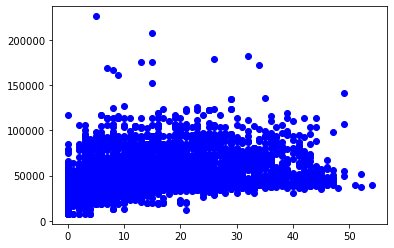

In [420]:
import matplotlib.pyplot as plt

plt.scatter(X,Y,color = "blue")

# Linear Regression

In [421]:
#Splitting dataset for training set and testing set
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.33,random_state = 0)

In [422]:
x_train

array([[ 4],
       [ 0],
       [39],
       ...,
       [20],
       [ 0],
       [21]])

In [423]:
y_train

array([43132.34, 43132.34, 53253.2 , ..., 51833.6 , 20592.  , 38987.73])

In [424]:
y_test

array([36223.2 , 39135.82, 26000.  , ..., 32448.83, 35899.97, 73617.65])

In [425]:
#Fitting Simple Linear regression to the training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)


LinearRegression()

In [426]:
#Predicting the Test set results
y_pred = regressor.predict(x_test)

In [427]:
#Displaying Predicted salary
y_pred

array([44502.45762055, 47713.31155673, 43860.28683331, ...,
       41291.60368436, 45786.79919502, 61841.06887596])

In [428]:
#Displaying Real salary
y_test  

array([36223.2 , 39135.82, 26000.  , ..., 32448.83, 35899.97, 73617.65])

In [429]:
#Calculating Error/ Residue
residue = y_pred - y_test    # residue or error between actual and predicted salary
residue

array([  8279.25762055,   8577.49155673,  17860.28683331, ...,
         8842.77368436,   9886.82919502, -11776.58112404])

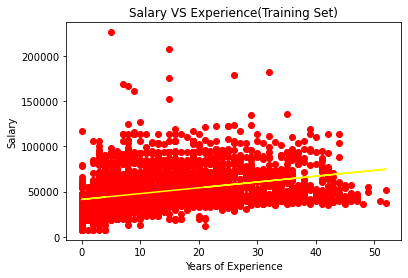

In [430]:
#Visualizing the training set results
plt.scatter(x_train,y_train,color="red")
plt.plot(x_train,regressor.predict(x_train),color="yellow")
plt.title("Salary VS Experience(Training Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

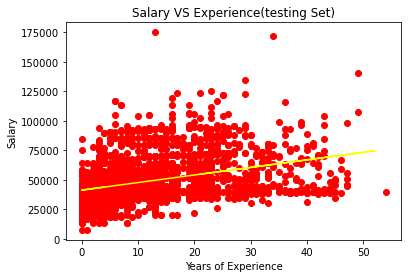

In [431]:
#Visualizing the testing set results
plt.scatter(x_test,y_test,color="Red")
plt.plot(x_train,regressor.predict(x_train),color="yellow")
plt.title("Salary VS Experience(testing Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [432]:
#Calculating Intercept and Coefficient
print(regressor.coef_)
print(regressor.intercept_)

[642.17078724]
41291.603684357186


In [433]:
#Model Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)                           #built-in function r2_score() indicates R-squared value 

print("RMSE =", rmse)
print("R2 Score=",r2)

RMSE = 18803.148408691188
R2 Score= 0.14287077460124398


In [434]:
regressor.predict([[25]])

array([57345.8733653])

# MULTILINEAR Regression


In [435]:
data.DEPARTMENT = pd.Categorical(data.DEPARTMENT)
data['Department_Code'] = data.DEPARTMENT.cat.codes
data.SEX = pd.Categorical(data.SEX) # FEMALE 0 MALE 1
data['SEX_Code'] = data.SEX.cat.codes
data.head()

,FIRST_NAME,LAST_NAME,DEPARTMENT,JOB_TITLE,ELECTED_OFFICIAL,DATE_STARTED,SEX,ETHNICITY,ORIG_START,DATE_TERM,PAY_STATUS,ANNUAL_SALARY,REGULAR_PAY,OVERTIME_PAY,INCENTIVE_PAY,GROSS_PAY,YEAR_EXPERIENCE,Department_Code,SEX_Code
0,DOMINIKA L,AARON,Human Services,CASEWORKER - CYF,0,2019-05-13,F,Black,2019-05-13,2019-05-31,Terminated,35821.34,1239.93,0.00,0.0,1239.93,0,15,0
1,CATHERINE,ABALO,Kane Regional Centers,NURSING ASSISTANT,0,2010-04-08,F,Black,2009-07-06,2022-07-10,Active,39771.47,43451.14,21377.48,0.0,64828.62,13,17,0
2,JOY M,ABBOTT,Kane Regional Centers,COOK,0,1999-02-14,F,White (Not of Hispanic Origin),1998-02-02,2022-07-10,Active,38987.73,39557.80,7826.11,125.0,47508.91,24,17,0
3,KEVIN J,ABBOTT,Emergency Management,FIRE INSTRUCTOR - PART TIME,0,2018-06-11,M,White (Not of Hispanic Origin),2018-06-11,2022-07-10,Active,30576.00,336.00,0.00,0.0,336.00,4,10,1
4,JEROME J,ABMAYR,Facilities Management,FOREMAN BUILDING MAINTENANCE,0,2010-05-10,M,White (Not of Hispanic Origin),2010-05-10,2019-03-29,Terminated,42975.30,18365.26,108.47,0.0,18473.73,8,12,1


In [436]:
df=data[['YEAR_EXPERIENCE','Department_Code','SEX_Code','ANNUAL_SALARY']]

In [437]:
df.head()

,YEAR_EXPERIENCE,Department_Code,SEX_Code,ANNUAL_SALARY
0,0,15,0,35821.34
1,13,17,0,39771.47
2,24,17,0,38987.73
3,4,10,1,30576.00
4,8,12,1,42975.30


In [438]:
from sklearn import linear_model
import statsmodels.api as sm
X = df.iloc[:, :3].values # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['ANNUAL_SALARY']
 
# with sklearn
regr = linear_model.LinearRegression()
regr.fit(X, Y)

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)

# prediction with sklearn
YEAR_EXPERIENCE = 25
Department_Code = 5
SEX_Code = 0 # FEMALE
print ('Predicted ANNUAL SALARY : \n', regr.predict([[YEAR_EXPERIENCE ,Department_Code,SEX_Code]]))

# with statsmodels
X = sm.add_constant(X) # adding a constant
 
model = sm.OLS(Y, X).fit()
predictions = model.predict(X) 
 
print_model = model.summary()
print(print_model)

Intercept: 
 38007.91379691966
Coefficients: 
 [ 642.34328626  -19.14225523 7088.18584892]
Predicted ANNUAL SALARY : 
 [53970.78467719]
                            OLS Regression Results                            
Dep. Variable:          ANNUAL_SALARY   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     409.8
Date:                Sun, 10 Jul 2022   Prob (F-statistic):          1.35e-244
Time:                        18:10:56   Log-Likelihood:                -76244.
No. Observations:                6769   AIC:                         1.525e+05
Df Residuals:                    6765   BIC:                         1.525e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.

In [439]:
X = df.iloc[:, :3].values # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['ANNUAL_SALARY']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=9)
lin_reg_mod = LinearRegression()
lin_reg_mod.fit(X_train, y_train)
pred = lin_reg_mod.predict(X_test)
test_set_rmse = (np.sqrt(mean_squared_error(y_test, pred)))

test_set_r2 = r2_score(y_test, pred)
print(test_set_rmse) # Note that for rmse, the lower that value is, the better the fit
print(test_set_r2) # The closer towards 1, the better the fit

17915.221166572002
0.1556722249546828


# Random Forest Regression

In [304]:
X = df.iloc[:, :3].values # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['ANNUAL_SALARY']
# Fitting the Regression Model to the dataset with 10 tree prediction
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [305]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [306]:
#Training the Algorithm
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=20, random_state=0)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [307]:
#Evaluating the Algorithm
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 10131.768401841138
Mean Squared Error: 208643588.4974275
Root Mean Squared Error: 14444.500285486774


In [308]:
regressor.predict([[25,5,0]]) # 25 years of experience in Dpeartment Code 5 and female

array([48376.3175])

In [310]:
#data.to_csv('dataset_clean.csv')

# Correlation Matrix 


In [320]:
correlation_matrix = df.corr()
correlation_matrix

,YEAR_EXPERIENCE,Department_Code,SEX_Code,ANNUAL_SALARY
YEAR_EXPERIENCE,1.000000,-0.046501,0.070549,0.352383
Department_Code,-0.046501,1.000000,0.082236,-0.007138
SEX_Code,0.070549,0.082236,1.000000,0.196395
ANNUAL_SALARY,0.352383,-0.007138,0.196395,1.000000


# Logistic Regression

In [368]:
X = df[['Department_Code','YEAR_EXPERIENCE','ANNUAL_SALARY']] # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['SEX_Code']
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [369]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.50


In [370]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[   0 1014]
 [   0 1017]]


we have 1017 correct predictions and 1014 inccorect predictions.

In [371]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1014
           1       0.50      1.00      0.67      1017

    accuracy                           0.50      2031
   macro avg       0.25      0.50      0.33      2031
weighted avg       0.25      0.50      0.33      2031



C:\Users\91981\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91981\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91981\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


The receiver operating characteristic (ROC) curve is another common tool used with binary classifiers. The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

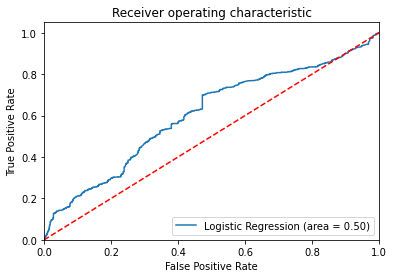

In [372]:
#ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Logistic Regression 2

In [373]:
X = df[['Department_Code','YEAR_EXPERIENCE']] # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['SEX_Code']
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [374]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.57


In [375]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[624 390]
 [478 539]]


we have 1063 correct predictions and 868 inccorect predictions.

In [376]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.62      0.59      1014
           1       0.58      0.53      0.55      1017

    accuracy                           0.57      2031
   macro avg       0.57      0.57      0.57      2031
weighted avg       0.57      0.57      0.57      2031



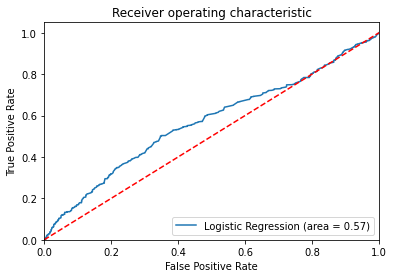

In [377]:
#ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Logistic Regression 3

In [379]:
X = df[['Department_Code']] # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['SEX_Code']
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [380]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.55


In [381]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[511 503]
 [403 614]]


we have 1125 correct predictions and 906 inccorect predictions.

In [382]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.50      0.53      1014
           1       0.55      0.60      0.58      1017

    accuracy                           0.55      2031
   macro avg       0.55      0.55      0.55      2031
weighted avg       0.55      0.55      0.55      2031



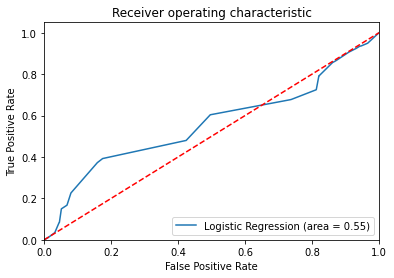

In [383]:
#ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Logistic Regression 4

In [384]:
X = df[['YEAR_EXPERIENCE']] # here we have 2 variables for multiple regression. If you just want to use one variable for simple linear regression, then use X = df['Interest_Rate'] for example.Alternatively, you may add additional variables within the brackets
Y = df['SEX_Code']
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [385]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.53


In [386]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[684 330]
 [634 383]]


we have 1067 correct predictions and 964 inccorect predictions.

In [387]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.67      0.59      1014
           1       0.54      0.38      0.44      1017

    accuracy                           0.53      2031
   macro avg       0.53      0.53      0.51      2031
weighted avg       0.53      0.53      0.51      2031



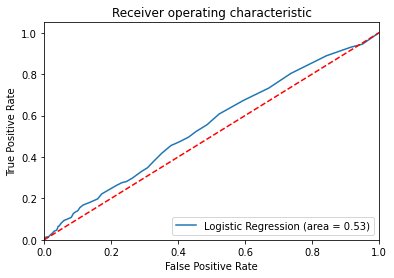

In [388]:
#ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()